<a href="https://colab.research.google.com/github/amelianiisrina/NiisrinaAmelia_2411532009_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# load dataset
dataset_url = 'https://raw.githubusercontent.com/amelianiisrina/NiisrinaAmelia_2411532009_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv'
df = pd.read_csv(dataset_url)
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


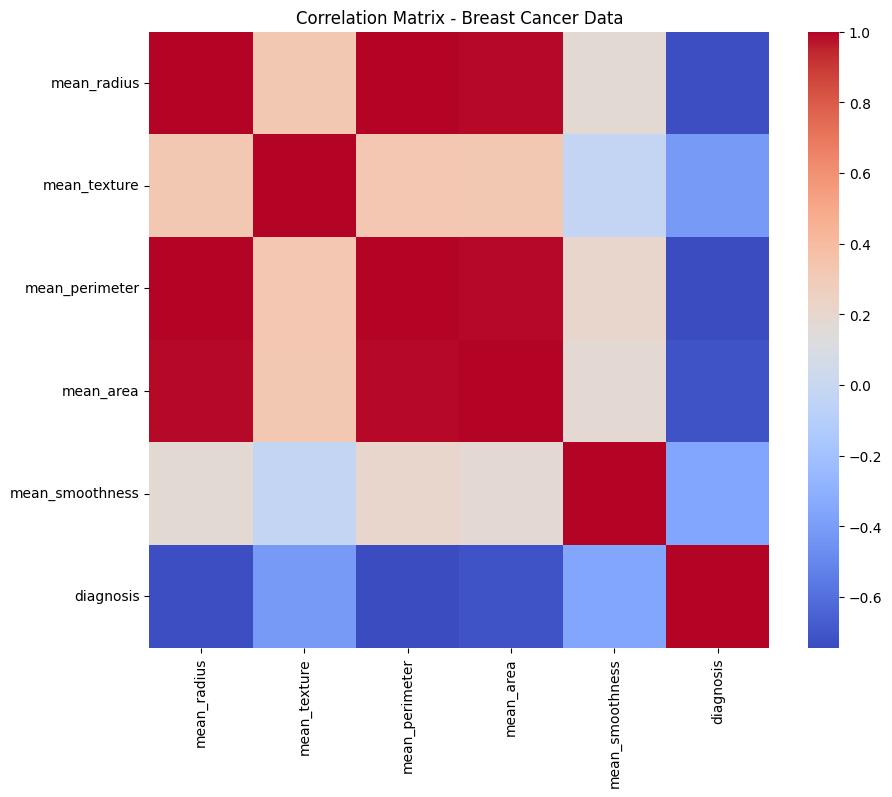

In [7]:
# correlation matrix
def plotCorrelationMatrix(df, graphWidth):
  filename = "Breast Cancer Data"
  df = df.select_dtypes(include=[np.number])

  corr = df.corr()

  plt.figure(figsize=(10,8))
  sns.heatmap(corr, cmap='coolwarm')
  plt.title("Correlation Matrix - Breast Cancer Data")
  plt.show()

plotCorrelationMatrix(df, 8)

In [8]:
# split dataset
feature_cols = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness']
X = df[feature_cols] # features
y = df.diagnosis # target

In [9]:
print(X.shape)
print(y.shape)

(569, 5)
(569,)


In [11]:
# split x dan y untuk data test dan data training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
model = LogisticRegression(random_state=12)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1])


Threshold: 0.3
Accuracy: 0.8947368421052632
[[ 48  16]
 [  2 105]]
              precision    recall  f1-score   support

           0       0.96      0.75      0.84        64
           1       0.87      0.98      0.92       107

    accuracy                           0.89       171
   macro avg       0.91      0.87      0.88       171
weighted avg       0.90      0.89      0.89       171



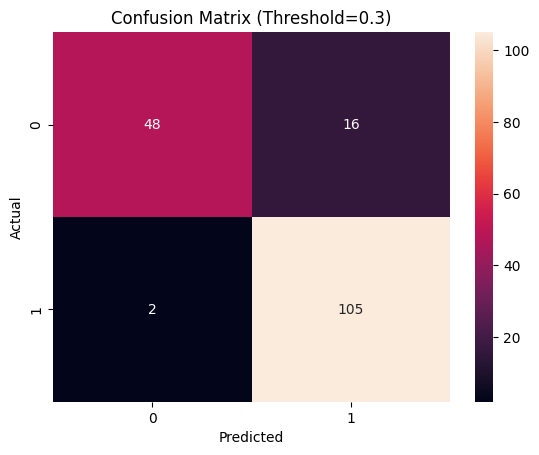


Threshold: 0.5
Accuracy: 0.8888888888888888
[[ 51  13]
 [  6 101]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        64
           1       0.89      0.94      0.91       107

    accuracy                           0.89       171
   macro avg       0.89      0.87      0.88       171
weighted avg       0.89      0.89      0.89       171



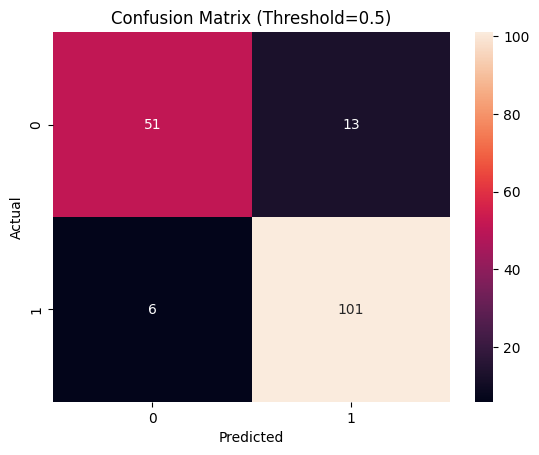


Threshold: 0.7
Accuracy: 0.9122807017543859
[[59  5]
 [10 97]]
              precision    recall  f1-score   support

           0       0.86      0.92      0.89        64
           1       0.95      0.91      0.93       107

    accuracy                           0.91       171
   macro avg       0.90      0.91      0.91       171
weighted avg       0.92      0.91      0.91       171



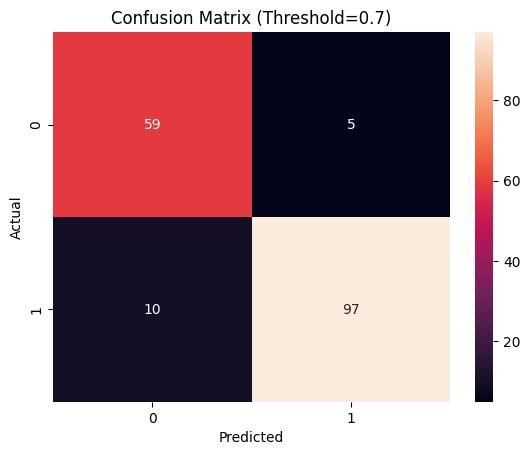

In [36]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
  y_pred = (y_prob >= t).astype(int)

  print(f"\nThreshold: {t}")
  print("Accuracy:", accuracy_score(y_test, y_pred))
  print(confusion_matrix(y_test, y_pred))
  print(classification_report(y_test, y_pred))

  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title(f'Confusion Matrix (Threshold={t})')
  plt.show()

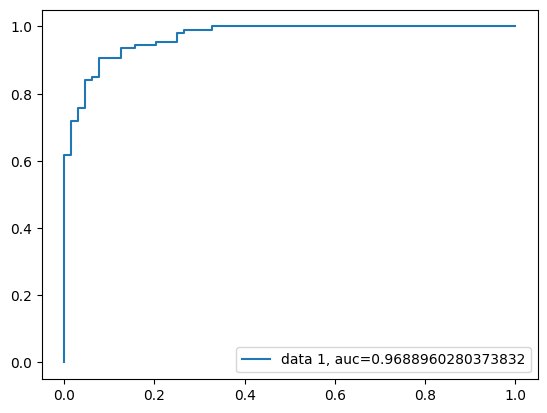

In [31]:
y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()

In [26]:
# model tanpa scaling
model_no_scaling = LogisticRegression()
model_no_scaling.fit(X_train, y_train)

y_pred_ns = model_no_scaling.predict(X_test)

print("Tanpa Scaling:", accuracy_score(y_test, y_pred_ns))

Tanpa Scaling: 0.8771929824561403


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
